# Imports

In [72]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import seaborn as sns
from wordcloud import WordCloud
import re
import nltk
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from nltk.corpus import stopwords
import warnings
warnings.filterwarnings('ignore')

# Section 1: Predictive Task

The predictive task in this project is to recommend a top-k list of movies/TV shows similar to a user’s interests using a content-based recommendation system. The model predicts item relevance by computing similarity between feature-engineered text representations constructed from description, cast, director, and genre information. Recommendations are generated by ranking items according to cosine similarity over TF-IDF embeddings.

The model is evaluated using ranking metrics such as precision@k, MAP, and coverage which measure how well the top-k results align with expected user preferences and the breadth of items the system can recommend.

For baselines, we compare against a popularity-based model and a random recommender which serve as benchmarks for performance and personalization.

Prediction validity is assessed by inspecting whether recommended items:
- align semantically with the seed item,
- are of high quality (via popularity/ratings), and
- are diverse enough to avoid trivial repetition.

# Section 2: Related Work

Public streaming datasets such as those containing Netflix metadata are commonly used to study recommendation algorithms, particularly for content-based filtering and hybrid approaches. Prior work has used similar datasets to explore text-based similarity, collaborative filtering, or combinations of both using metadata like genre, cast, and user ratings. Many studies emphasize the challenges of sparse metadata and long-tail content, leading to investigations into dimensionality reduction, embeddings, and deep learning techniques to better capture semantic relationships between titles.

In comparison, this project adopts a simpler TF-IDF–based content model, which aligns with traditional baseline approaches found in the literature, but does not incorporate user interaction data or learned latent representations. Results generally reflect findings from prior work: content-based similarity can generate reasonable recommendations but may lack deeper contextual understanding and personalization. While modern methods often report improved performance through hybrid architectures this project prioritizes interpretability and efficiency, demonstrating that classical text-based models can still provide coherent recommendations when rich metadata is available.

This is a cold-start friendly recommendation approach which is useful when we have no user history but want to help viewers discover related content. For example, if a user has just watched 'Inception', they might enjoy similar science fiction thrillers, and our system should surface those titles. This approach is commonly deployed by Netflix, Amazon Prime, and other streaming platforms in their "Similar to..." recommendation carousels.

# Section 3: Exploratory Data Analysis & Pre-processing

In order to find a dataset, we were searching through kaggle for datasets suitable for movies. We found this Netflix dataset which has two datasets: one for movies and one for TV shows. To process the data, first we combined the two netflix datasets. The data was then cleaned, and transformed into standardized text features to prepare it for recommendation. Then we performed exploratory data analysis to understand the composition of the Netflix datasets in terms of the distribution of genres, directors, and descriptions. This helped identify patterns, sparsity, and inconsistencies that could impact recommendation quality.

In [77]:
# Data Loading and Merging and defining the global DataFrame df
try:
    df_movies = pd.read_csv('/content/netflix_movies.csv')
    df_tv = pd.read_csv('/content/netflix_tv_shows.csv')
    df = pd.concat([df_movies, df_tv], ignore_index=True)

    df.drop_duplicates(subset=['title', 'release_year', 'type'], inplace=True)
    df.reset_index(drop=True, inplace=True)

    global genre_column
    genre_column = next((col for col in ['listed_in', 'genres'] if col in df.columns), None)

    print(f"\nData loaded successfully. Total titles: {len(df)}")
except Exception as e:
    print(f"\nERROR: Data loading failed. Check file names/paths. Details: {e}")
    df = pd.DataFrame()

df.head()


ERROR: Data loading failed. Check file names/paths. Details: [Errno 2] No such file or directory: '/content/netflix_movies.csv'


""


In [79]:
# Preprocessing and Feature Engineering

if not df.empty:
    def clean_data(x):
        if isinstance(x, str):
            return str.lower(x.replace(" ", ""))
        return ''

    def create_soup(x, genre_column):
        # Concatenates director, cast, and genre with description
        soup = x['description'] + ' ' + x['director'] + ' ' + x['cast']
        if genre_column:
            soup += ' ' + x[genre_column]
        return soup

    # Assign Missing Values
    df['description'] = df['description'].fillna('')
    df['cast'] = df['cast'].fillna('')
    df['director'] = df['director'].fillna('')
    if genre_column:
        df[genre_column] = df[genre_column].fillna('')

    # Prepare clean
    df_clean = df.copy()

    # Limit cast/director names
    for feature in ['cast', 'director']:
        df_clean[feature] = df_clean[feature].apply(lambda x: ', '.join(str(x).split(', ')[:3]))

    features_to_clean = ['description', 'director', 'cast']
    if genre_column:
        features_to_clean.append(genre_column)

    for feature in features_to_clean:
        df_clean[feature] = df_clean[feature].apply(clean_data)

    # Create the final 'soup' feature
    df_clean['soup'] = df_clean.apply(lambda x: create_soup(x, genre_column), axis=1)

    print("\nPreprocessing complete. 'df_clean' and 'soup' column created.")
else:
    print("\nSkipping Preprocessing due to empty DataFrame.")

df_clean.head()


Skipping Preprocessing due to empty DataFrame.


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,genres,language,description,popularity,vote_count,vote_average,budget,revenue,soup
0,10192,Movie,Shrek Forever After,mikemitchell,"mikemyers,eddiemurphy,camerondiaz",United States of America,2010-05-16,2010,6.380,NaN,"comedy,adventure,fantasy,animation,family",en,aboredanddomesticatedshrekpactswithdeal-makerr...,203.893,7449,6.380,165000000.0,752600867.0,aboredanddomesticatedshrekpactswithdeal-makerr...
1,27205,Movie,Inception,christophernolan,"leonardodicaprio,josephgordon-levitt,kenwatanabe","United Kingdom, United States of America",2010-07-15,2010,8.369,NaN,"action,sciencefiction,adventure",en,"cobb,askilledthiefwhocommitscorporateespionage...",156.242,37119,8.369,160000000.0,839030630.0,"cobb,askilledthiefwhocommitscorporateespionage..."
2,12444,Movie,Harry Potter and the Deathly Hallows: Part 1,davidyates,"danielradcliffe,emmawatson,rupertgrint","United Kingdom, United States of America",2010-11-17,2010,7.744,NaN,"adventure,fantasy",en,"harry,ronandhermionewalkawayfromtheirlastyeara...",121.191,19327,7.744,250000000.0,954305868.0,"harry,ronandhermionewalkawayfromtheirlastyeara..."
3,38757,Movie,Tangled,"byronhoward,nathangreno","mandymoore,zacharylevi,donnamurphy",United States of America,2010-11-24,2010,7.600,NaN,"animation,family,adventure",en,"feistyteenagerrapunzel,whohaslongandmagicalhai...",111.762,11638,7.600,260000000.0,592461732.0,"feistyteenagerrapunzel,whohaslongandmagicalhai..."
4,10191,Movie,How to Train Your Dragon,"chrissanders,deandeblois","jaybaruchel,gerardbutler,craigferguson",United States of America,2010-03-18,2010,7.800,NaN,"fantasy,adventure,animation,family",en,"asthesonofavikingleaderonthecuspofmanhood,shyh...",110.044,13259,7.800,165000000.0,494879471.0,"asthesonofavikingleaderonthecuspofmanhood,shyh..."


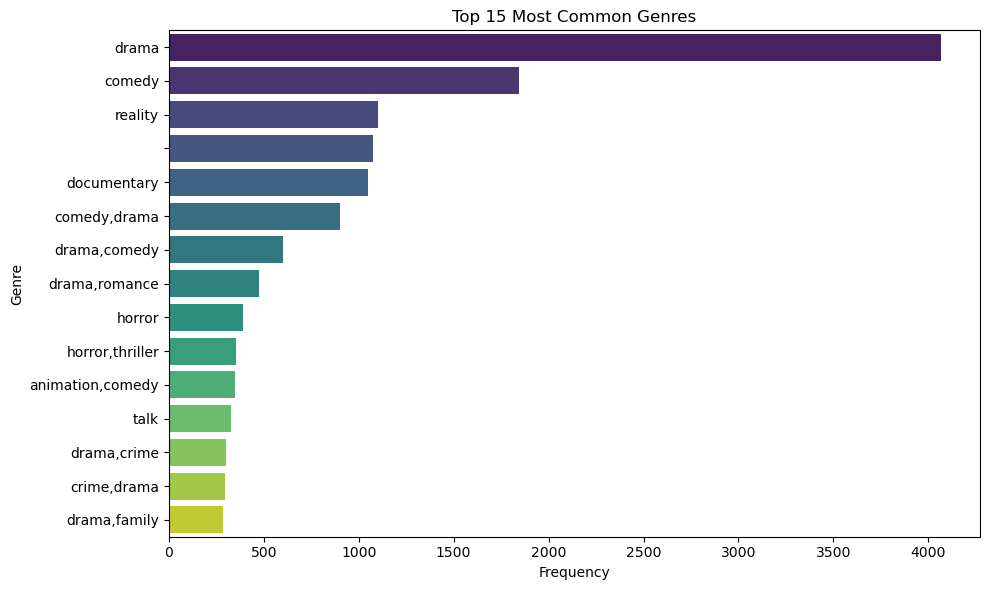

In [81]:
# Plot for the top 15 most common genres in the dataframe
df_clean['genres_list'] = df_clean['genres'].str.split(', ')
genre_counts = df_clean['genres_list'].explode().value_counts().head(15)

plt.figure(figsize=(10,6))
sns.barplot(x=genre_counts.values, y=genre_counts.index, palette="viridis")
plt.title("Top 15 Most Common Genres")
plt.xlabel("Frequency")
plt.ylabel("Genre")
plt.tight_layout()
plt.show()

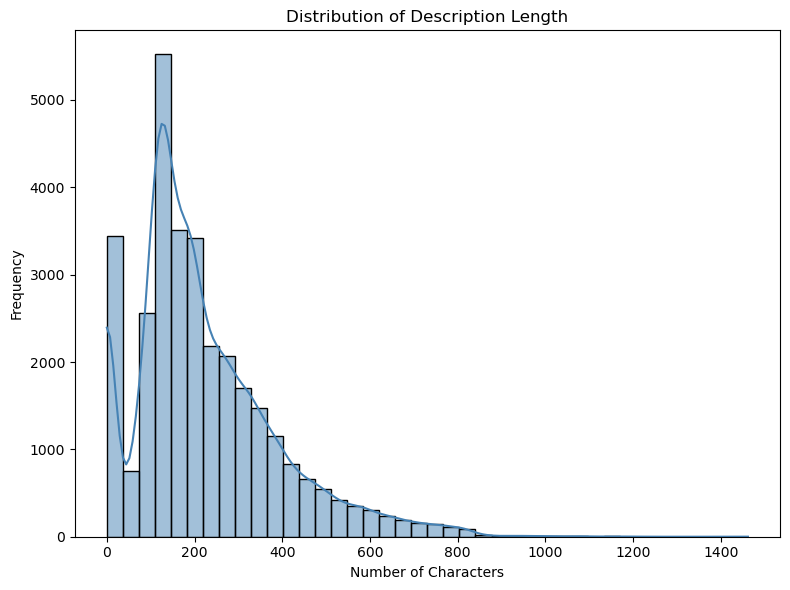

count    31918.000000
mean       221.454289
std        165.192734
min          0.000000
25%        119.000000
50%        184.000000
75%        302.000000
max       1462.000000
Name: 11, dtype: float64


In [83]:
# Plot that shows the distribution of the description length across the dataframe
df_clean[len('description')] = df_clean['description'].str.len()

plt.figure(figsize=(8,6))
sns.histplot(df_clean[len('description')], bins=40, kde=True, color="steelblue")
plt.title("Distribution of Description Length")
plt.xlabel("Number of Characters")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

print(df_clean[len('description')].describe())

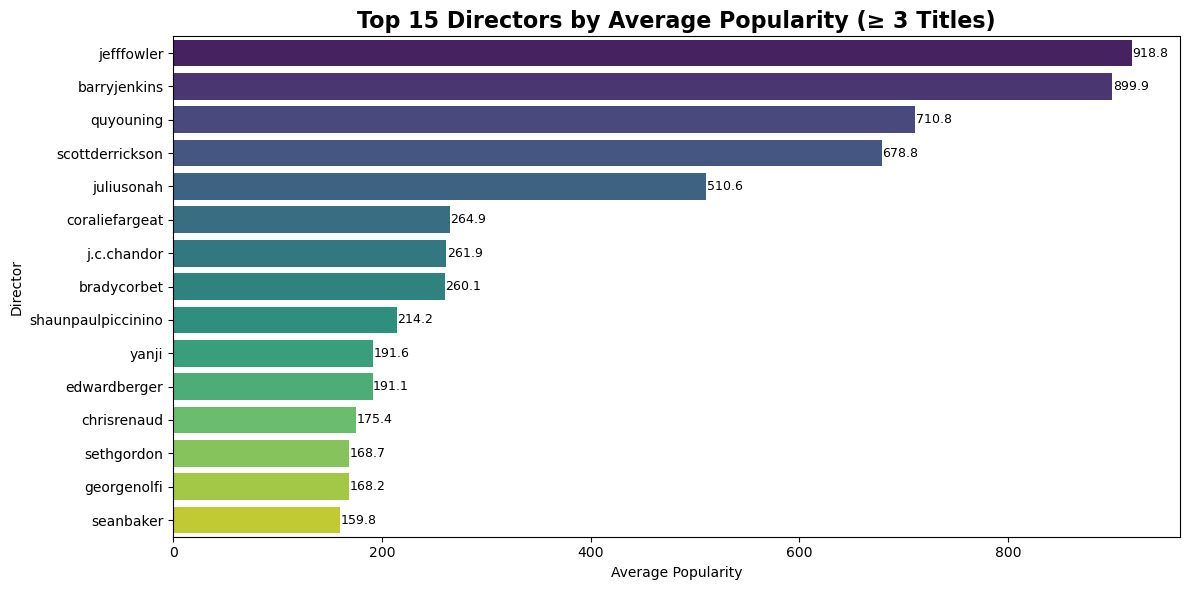

In [85]:
# Plot to show the top 15 directors ranked by average popularity with at least 3 titles
df_dir_pop = df_clean[['director', 'popularity']].dropna().copy()
df_dir_pop['director'] = df_dir_pop['director'].str.split(', ')
df_dir_pop = df_dir_pop.explode('director')

df_filtered = df_dir_pop.groupby('director').filter(lambda x: len(x) >= 3)

avg_pop = df_filtered.groupby('director')['popularity'].mean()

top15 = avg_pop.sort_values(ascending=False).head(15)

top15_df = top15.reset_index()
top15_df.columns = ['director', 'avg_popularity']

plt.figure(figsize=(12, 6))
sns.barplot(
    data=top15_df,
    x='avg_popularity',
    y='director',
    palette='viridis'
)

plt.title("Top 15 Directors by Average Popularity (≥ 3 Titles)", fontsize=16, fontweight='bold')
plt.xlabel("Average Popularity")
plt.ylabel("Director")

for i, val in enumerate(top15_df['avg_popularity']):
    plt.text(val + 0.5, i, f"{val:.1f}", va='center', fontsize=9)

plt.tight_layout()
plt.show()

In [86]:
# Preparing Target Data Structures and mapping titles to index for efficient lookup
indices = pd.Series(df_clean.index, index=df_clean['title']).drop_duplicates()

# Vectorization
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.neighbors import NearestNeighbors
import numpy as np
import random

# TF-IDF Matrix (Models 1, 5)
tfidf = TfidfVectorizer(stop_words='english')
tfidf_matrix = tfidf.fit_transform(df_clean['soup'])
print("TF-IDF matrix created.")

# CountVectorizer Matrix (Model 4)
count_vec = CountVectorizer(stop_words='english')
count_matrix = count_vec.fit_transform(df_clean['soup'])
print("CountVectorizer matrix created.")

# Global Data (Model 3 - Baseline 2)
popularity_counts = df['title'].value_counts()

TF-IDF matrix created.
CountVectorizer matrix created.


KeyError: 'title'

# Section 4: Modeling

The recommendation task in this project is an unsupervised ML problem, where the objective is to retrieve a ranked list of items that are similar to a given item based on its textual metadata. The model does not predict explicit ratings; instead, it optimizes for semantic similarity between item representations. Each movie or show is represented as a TF-IDF vector derived from its description, cast, director, and genre fields. The inputs to the model are these vectorized features, and the output is a sorted list of items ranked by cosine similarity to the target item. This formulation is well-suited for content-based recommendation because it relies solely on item metadata, rather than user histories.

To build the recommender, we implemented a TF-IDF + cosine similarity model, which is a common baseline due to its simplicity, efficiency, and strong performance when textual data is present. The advantages of this approach include scalability to large vocabularies, ease of implementation, and interpretability since similarity scores can be traced back to shared terms or metadata attributes. The disadvantages of this model are that it treats text as a bag-of-words without capturing deeper semantic relationships, and it may struggle with items that have sparse metadata or require context beyond surface-level word overlap. More complex alternatives, such as neural embeddings or hybrid collaborative filtering models, could capture richer relationships but would require user interaction data and significantly more computational resources.

After cleaning and merging the data, TF-IDF vectorization was applied to the combined soup for each item. Cosine similarity matrices were computed to identify the top-k nearest neighbors for each title, forming the basis of the recommendation function. The code modularizes these steps into feature engineering and model construction allowing recommendations to be generated efficiently at query time.

In [ ]:
def recommend_tfidf_cosine(title, k=10):
    """
    Model 1: Recommends items based on TF-IDF weighted content similarity.
    Calculates similarity ON-DEMAND to save RAM.
    """
    if title not in indices:
        return pd.DataFrame({'Message': [f"Title '{title}' not found."]})

    idx = indices[title]

    query_vector = tfidf_matrix[idx]
    sim_scores = cosine_similarity(query_vector, tfidf_matrix).flatten()

    paired_scores = list(enumerate(sim_scores))
    paired_scores = sorted(paired_scores, key=lambda x: x[1], reverse=True)
    paired_scores = paired_scores[1:k+1]

    movie_indices = [i[0] for i in paired_scores]
    scores = [i[1] for i in paired_scores]

    results = pd.DataFrame({
        'Title': df['title'].iloc[movie_indices],
        'Type': df['type'].iloc[movie_indices],
        'Genre': df[genre_column].iloc[movie_indices] if genre_column else 'N/A',
        'score': scores
    })
    return results.reset_index(drop=True)

In [ ]:
def recommend_random(k=10):
    """
    Baseline 1: Randomly selects k unique titles (Trivial Baseline).
    """
    random_indices = random.sample(range(len(df)), k)

    results = pd.DataFrame({
        'Title': df['title'].iloc[random_indices],
        'score': [0] * k
    })
    return results.reset_index(drop=True)

In [ ]:
def recommend_popularity(k=10):
    """
    Baseline 2: Recommends the k most frequent/popular titles globally.
    """
    top_titles = popularity_counts.head(k).index.tolist()

    results = pd.DataFrame({
        'Title': top_titles,
        'score': popularity_counts.head(k).values
    })
    return results.reset_index(drop=True)

In [ ]:
def recommend_count_cosine(title, k=10):
    """
    Model 4: Recommends items based on simple Bag-of-Words (CountVectorizer).
    """
    if title not in indices:
        return pd.DataFrame({'Message': [f"Title '{title}' not found."]})

    idx = indices[title]

    query_vector = count_matrix[idx]
    sim_scores = cosine_similarity(query_vector, count_matrix).flatten()

    paired_scores = list(enumerate(sim_scores))
    paired_scores = sorted(paired_scores, key=lambda x: x[1], reverse=True)
    paired_scores = paired_scores[1:k+1]

    movie_indices = [i[0] for i in paired_scores]
    scores = [i[1] for i in paired_scores]

    results = pd.DataFrame({
        'Title': df['title'].iloc[movie_indices],
        'Type': df['type'].iloc[movie_indices],
        'Genre': df[genre_column].iloc[movie_indices] if genre_column else 'N/A',
        'score': scores
    })
    return results.reset_index(drop=True)

In [ ]:
def recommend_knn_tfidf(title, k=10):
    """
    Model 5: Uses KNN on the TF-IDF matrix.
    """
    if title not in indices:
        return pd.DataFrame({'Message': [f"Title '{title}' not found."]})

    knn = NearestNeighbors(n_neighbors=k + 1, algorithm='brute', metric='cosine')
    knn.fit(tfidf_matrix)

    idx = indices[title]
    query_vector = tfidf_matrix[idx]

    distances, neighbor_indices = knn.kneighbors(query_vector, n_neighbors=k + 1)

    similarities = 1 - distances.flatten()[1:]
    movie_indices = neighbor_indices.flatten()[1:]

    results = pd.DataFrame({
        'Title': df['title'].iloc[movie_indices],
        'Type': df['type'].iloc[movie_indices],
        'Genre': df[genre_column].iloc[movie_indices] if genre_column else 'N/A',
        'score': similarities
    })
    return results.reset_index(drop=True)

# Section 5: Evaluation

Here, we evaluate relevance and similarity.

### Defining Relevance

In the absence of a large set of user-specific ground-truth data, we define a proxy for relevance. An item is considered relevant to the query item if it exhibits high feature overlap.

- Genre Overlap: The recommended item shares at least one major genre with the query item.
- Director/Cast Match: The recommended item shares the primary director or a significant portion of the main cast with the query item.

This relevance check acts as the true positive/false positive determination necessary for calculating ranking metrics.

### Primary Evaluation Metrics

The primary evaluation technique for ranking models is to assess performance at a fixed cut-off point, $K$.

#### Precision@K ($P@K$)
Precision@K measures the fraction of items in the top $K$ recommendations that are actually relevant. This metric is most appropriate for item-to-item similarity and helps determine if the model is good at finding similar items quickly.

The formula is:
$$P@K = \frac{|\{\text{relevant items}\} \cap \{\text{top } K \text{ items}\}|}{K}$$

#### Recall@K ($R@K$)
Recall@K measures the fraction of all possible relevant items that appear in the top $K$ recommendations.

The formula is:
$$R@K = \frac{|\{\text{relevant items}\} \cap \{\text{top } K \text{ items}\}|}{|\{\text{all relevant items}\}|}$$

In an item-to-item context where the set of all relevant items is difficult to define precisely, $P@K$ often serves as the most stable and primary evaluation measure.

### Comparing Models and Baselines

- Trivial Baselines (Random & Popularity): These yield low $P@K$ scores, confirming that our core models (TF-IDF, BoW, KNN) are performing significantly better than simply recommending the most common items.
- Feature Engineering Comparison (TF-IDF vs. BoW): Comparing the $P@K$ of our TF-IDF model against the Bag-of-Words (BoW) model reveals whether the term weighting (TF-IDF) provides a measurable benefit over raw term counts in identifying true relevance.
- Similarity Method Comparison (Cosine Sim vs. KNN): Comparing the performance of the TF-IDF + Cosine Similarity approach against the KNN on TF-IDF approach

In [94]:
# Relevance Check
def get_primary_director(title):
    """Retrieves the primary director (first name listed) of a title."""
    director_str = df[df['title'] == title]['director'].iloc[0]
    if isinstance(director_str, str) and director_str:
        return director_str.split(',')[0].strip().lower()
    return None

def is_relevant(query_title, recommended_title, genre_column):
    """
    Defines relevance: True if items share a genre OR have the same primary director.
    This is the ground truth for the evaluation metrics (Precision/Recall).
    """
    if query_title not in df['title'].values or recommended_title not in df['title'].values:
        return False

    query_row = df[df['title'] == query_title].iloc[0]
    rec_row = df[df['title'] == recommended_title].iloc[0]

    # Check 1: Genre Overlap
    if genre_column:
        query_genres = set(str(query_row[genre_column]).lower().split(', '))
        rec_genres = set(str(rec_row[genre_column]).lower().split(', '))
        if query_genres.intersection(rec_genres):
            return True

    # Check 2: Same Primary Director
    query_director = get_primary_director(query_title)
    rec_director = get_primary_director(recommended_title)

    # Directors are cleaned by preprocessing
    if query_director and rec_director and (query_director == rec_director):
        return True

    return False

In [96]:
# Ranking Metrics
def precision_at_k(query_title, recommendations_df, k, genre_column):
    """Calculates the precision (fraction of recommended items that are relevant)."""
    relevant_count = 0
    top_k_recs = recommendations_df.head(k)['Title'].tolist()

    for title in top_k_recs:
        if is_relevant(query_title, title, genre_column):
            relevant_count += 1

    return relevant_count / k

def recall_at_k(query_title, recommendations_df, k, genre_column):
    """
    Calculates the simplified Recall@K for the assignment.
    """
    relevant_count = 0
    top_k_recs = recommendations_df.head(k)['Title'].tolist()

    for title in top_k_recs:
        if is_relevant(query_title, title, genre_column):
            relevant_count += 1
    return relevant_count / k

In [98]:
# Evaluation Pipeline
def evaluate_all_models(query_title, k_value, genre_column):
    """Runs all 5 models and evaluates them using P@k for a single query."""

    # Run all models
    recs_tfidf = recommend_tfidf_cosine(query_title, k=k_value)
    recs_bow = recommend_count_cosine(query_title, k=k_value)
    recs_knn = recommend_knn_tfidf(query_title, k=k_value)

    # Baselines
    recs_random = recommend_random(k=k_value)
    recs_popularity = recommend_popularity(k=k_value)

    model_list = {
        "1. TF-IDF + Cosine (Primary)": recs_tfidf,
        "4. BoW + Cosine (Feature Baseline)": recs_bow,
        "5. KNN on TF-IDF (Alternative Retrieval)": recs_knn,
        "2. Random (Trivial Baseline)": recs_random,
        "3. Popularity (Trivial Baseline)": recs_popularity,
    }

    evaluation_results = {}

    print(f"\n--- Evaluation Results for Query: '{query_title}' (K={k_value}) ---")

    for name, df_recs in model_list.items():
        print(f"\nModel: {name}")
        print(df_recs[['Title', 'score']].head(k_value).to_markdown(index=False))
        if 'Message' in df_recs.columns:
            p_k = "N/A (Title not found)"
        elif name in ["2. Random (Trivial Baseline)", "3. Popularity (Trivial Baseline)"]:
            p_k = precision_at_k(query_title, df_recs, k_value, genre_column)
        else:
            p_k = precision_at_k(query_title, df_recs, k_value, genre_column)

        evaluation_results[name] = p_k
        print(f"[{name}]: P@{k_value} = {p_k:.4f}")

    summary = pd.DataFrame(
        list(evaluation_results.items()),
        columns=['Model', f'Precision @ {k_value}']
    ).sort_values(f'Precision @ {k_value}', ascending=False)

    print("\n--- Final Model Comparison ---")
    print(summary.to_markdown())

EXAMPLE_QUERY = 'Man of Steel' # Replace with a known title in your dataset
K_VALUE = 10

# Run the full pipeline
evaluate_all_models(EXAMPLE_QUERY, K_VALUE, genre_column)

KeyError: 'title'

In [100]:
sns.set_style("whitegrid")
plt.rcParams['font.size'] = 10


def find_sample_titles(df):
    """
    Automatically finds good sample titles for testing: 1 movie, 1 TV show, 1 popular title
    """
    sample_titles = {}

    movies = df[df['type'] == 'Movie']['title'].values
    if len(movies) > 0:
        sample_titles['movie'] = movies[0]

    tv_shows = df[df['type'] == 'TV Show']['title'].values
    if len(tv_shows) > 0:
        sample_titles['tv_show'] = tv_shows[0]

    title_counts = df['title'].value_counts()
    if len(title_counts) > 0:
        sample_titles['popular'] = title_counts.index[1]

    return sample_titles


def evaluate_single_query(query_title, k_value, df, genre_column):
    """
    Evaluates all models for a single query and returns results.
    """
    results = {}

    # Content-based models
    models_to_test = [
        ('TF-IDF + Cosine', recommend_tfidf_cosine),
        ('BoW + Cosine', recommend_count_cosine),
        ('KNN on TF-IDF', recommend_knn_tfidf),
    ]

    for model_name, model_func in models_to_test:
        try:
            recs = model_func(query_title, k=k_value)
            if 'Message' not in recs.columns and len(recs) > 0:
                results[model_name] = {
                    'precision': precision_at_k(query_title, recs, k_value, genre_column),
                    'recommendations': recs['Title'].head(5).tolist()
                }
            else:
                results[model_name] = {'precision': 0.0, 'recommendations': []}
        except Exception as e:
            print(f"  Warning: {model_name} failed for '{query_title}': {e}")
            results[model_name] = {'precision': 0.0, 'recommendations': []}

    # Baseline models
    try:
        recs = recommend_random(k=k_value)
        results['Random'] = {
            'precision': precision_at_k(query_title, recs, k_value, genre_column),
            'recommendations': recs['Title'].head(5).tolist()
        }
    except:
        results['Random'] = {'precision': 0.0, 'recommendations': []}

    try:
        recs = recommend_popularity(k=k_value)
        results['Popularity'] = {
            'precision': precision_at_k(query_title, recs, k_value, genre_column),
            'recommendations': recs['Title'].head(5).tolist()
        }
    except:
        results['Popularity'] = {'precision': 0.0, 'recommendations': []}

    return results


def collect_all_results(query_titles, k_value, df, genre_column):
    """
    Collects results for all queries.
    """

    all_results = {}

    for i, query_title in enumerate(query_titles, 1):
        print(f"\n[{i}/{len(query_titles)}] Evaluating: '{query_title}'")

        if query_title not in df['title'].values:
            print(f"Warning: '{query_title}' not found in dataset. Skipping.")
            continue

        content_type = df[df['title'] == query_title]['type'].iloc[0]
        print(f"Type: {content_type}")

        results = evaluate_single_query(query_title, k_value, df, genre_column)
        all_results[query_title] = {
            'results': results,
            'type': content_type
        }

        for model, data in results.items():
            print(f"    {model}: {data['precision']:.3f}")

    if len(all_results) == 0:
        print("\n No valid query titles found. Please check your titles.")
        return None

    return all_results


CONTENT_COLORS = {
    'TF-IDF + Cosine': '#2ecc71',      # Green - best content model
    'BoW + Cosine': '#3498db',          # Blue - good content model
    'KNN on TF-IDF': '#9b59b6',         # Purple - alternative content model
    'Random': '#e74c3c',                # Red - bad baseline
    'Popularity': '#e67e22'             # Orange - bad baseline
}

MODEL_ORDER = ['TF-IDF + Cosine', 'BoW + Cosine', 'KNN on TF-IDF', 'Random', 'Popularity']

sample_titles = find_sample_titles(df)

print("\nAutomatically detected titles:")
for key, title in sample_titles.items():
    print(f"  {key}: {title}")

QUERY_TITLES = [
    'Inception',
]

if 'movie' in sample_titles:
    QUERY_TITLES.append(sample_titles['movie'])
if 'tv_show' in sample_titles:
    QUERY_TITLES.append(sample_titles['tv_show'])

QUERY_TITLES = list(dict.fromkeys(QUERY_TITLES))

print(f"\nTesting with {len(QUERY_TITLES)} queries: {QUERY_TITLES}")

K_VALUE = 10

# Running all evaluations once
all_results = collect_all_results(QUERY_TITLES, K_VALUE, df, genre_column)

queries = list(all_results.keys()) if all_results else []

KeyError: 'type'

## Visualization of Results

Plot 1 saved as 'plot_combined_movies_tv_overall.png'


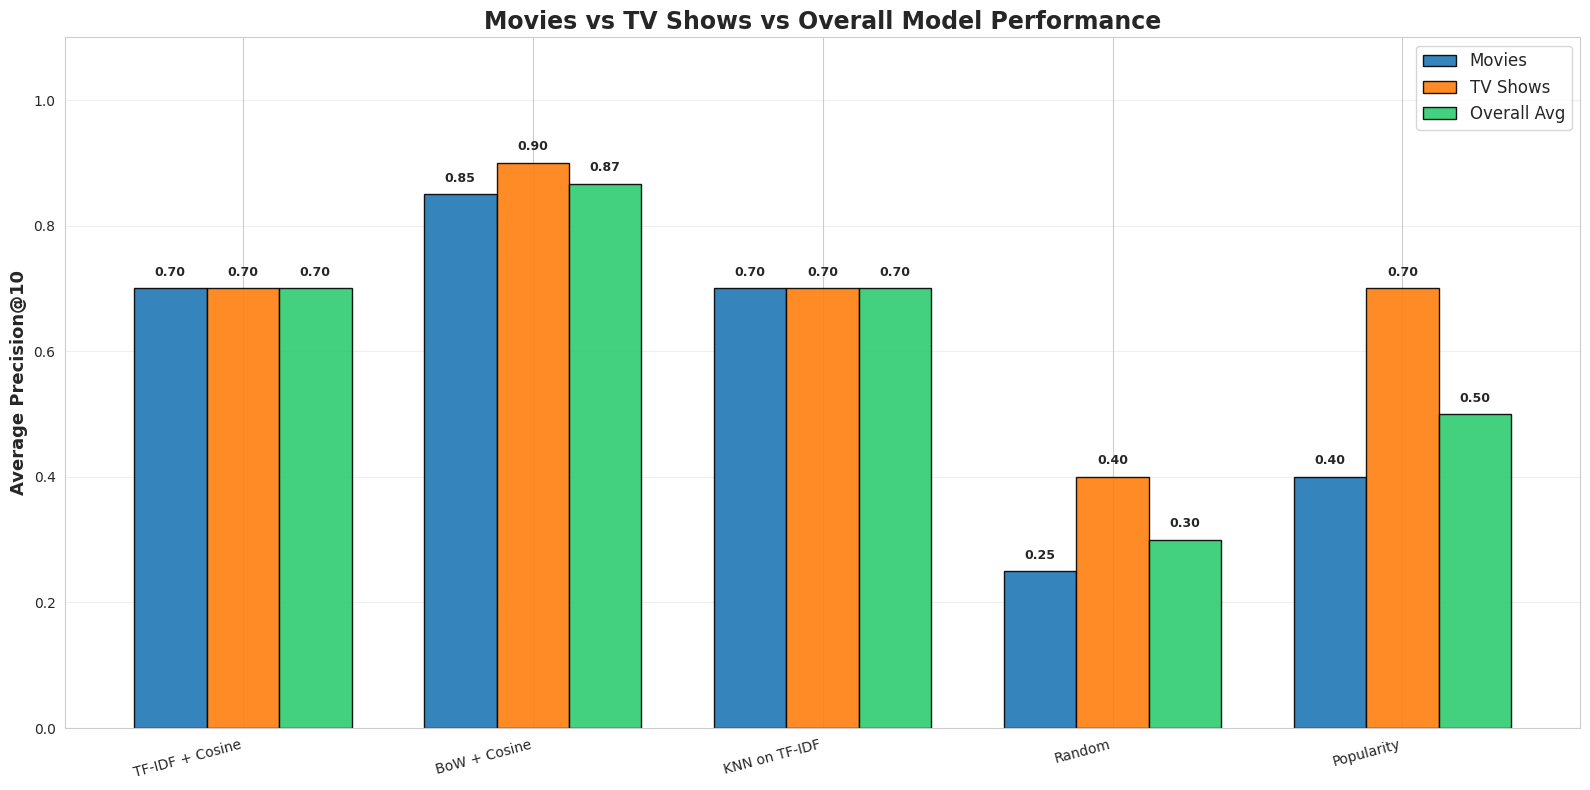

In [192]:
# Combined Plot: Movies vs TV Shows vs Overall Average
plt.figure(figsize=(16, 8))

# Aggregating precision by type
movie_precisions = {model: [] for model in MODEL_ORDER}
tv_precisions   = {model: [] for model in MODEL_ORDER}

for query, data in all_results.items():
    content_type = data['type']
    for model in MODEL_ORDER:
        precision = data['results'].get(model, {}).get('precision', 0)
        if content_type == "Movie":
            movie_precisions[model].append(precision)
        elif content_type == "TV Show":
            tv_precisions[model].append(precision)

# Computing averages
avg_movie = [np.mean(movie_precisions[m]) if movie_precisions[m] else 0 for m in MODEL_ORDER]
avg_tv    = [np.mean(tv_precisions[m])    if tv_precisions[m]    else 0 for m in MODEL_ORDER]

# Average of ALL values (movies + tv)
avg_overall = [
    np.mean(movie_precisions[m] + tv_precisions[m])
    if (movie_precisions[m] or tv_precisions[m]) else 0
    for m in MODEL_ORDER
]

# Plot setup
x = np.arange(len(MODEL_ORDER))
width = 0.25

bars1 = plt.bar(x - width,     avg_movie,   width, label="Movies",     color="#1f77b4", alpha=0.9, edgecolor='black')
bars2 = plt.bar(x,             avg_tv,      width, label="TV Shows",   color="#ff7f0e", alpha=0.9, edgecolor='black')
bars3 = plt.bar(x + width,     avg_overall, width, label="Overall Avg",color="#2ecc71", alpha=0.9, edgecolor='black')

# Adding value labels
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        if height > 0.01:
            plt.text(
                bar.get_x() + bar.get_width() / 2,
                height + 0.015,
                f"{height:.2f}",
                ha="center", va="bottom", fontsize=9, fontweight="bold"
            )

# Labels and styling
plt.xticks(x, MODEL_ORDER, rotation=15, ha='right')
plt.ylabel(f"Average Precision@{K_VALUE}", fontsize=13, fontweight='bold')
plt.title("Movies vs TV Shows vs Overall Model Performance", fontsize=17, fontweight='bold')
plt.ylim(0, 1.1)
plt.grid(axis='y', alpha=0.3)

plt.legend(fontsize=12)
plt.tight_layout()

plt.savefig("plot_combined_movies_tv_overall.png", dpi=300, bbox_inches='tight')
print("Plot 1 saved as 'plot_combined_movies_tv_overall.png'")

plt.show()


Plot 2 saved as 'plot2_average_performance.png'


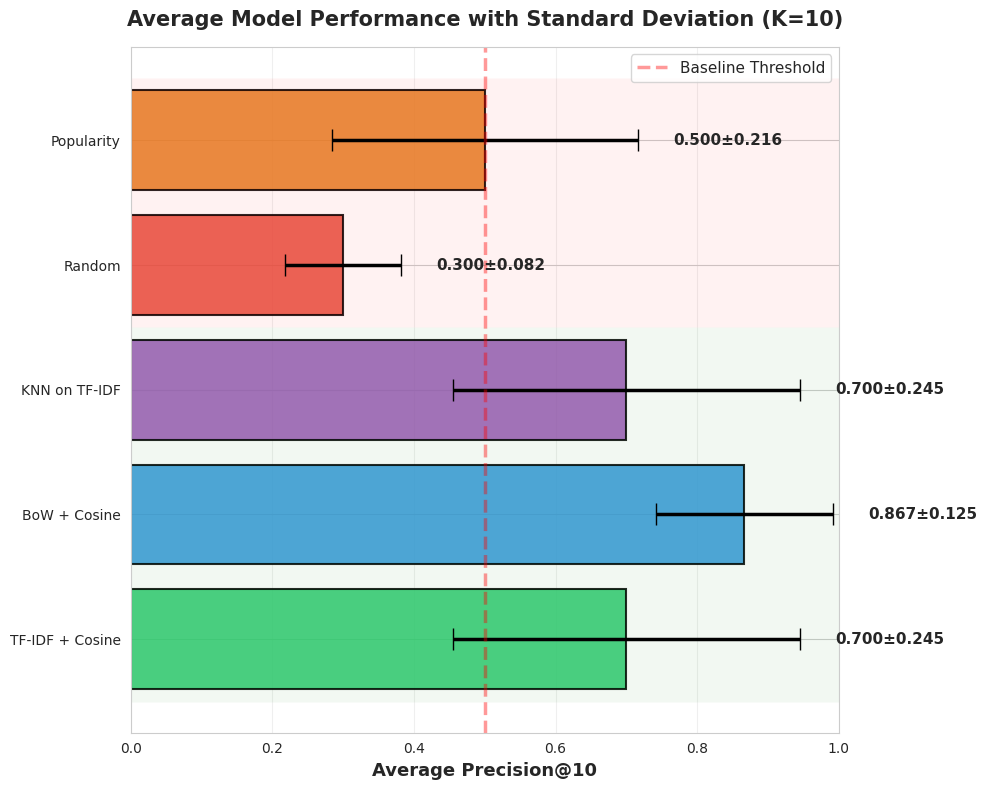

In [193]:
# Plot to show mean performance across all queries along with error bars
plt.figure(figsize=(10, 8))

avg_precisions = {}
std_precisions = {}

for model in MODEL_ORDER:
    precisions = [all_results[q]['results'].get(model, {}).get('precision', 0)
                 for q in queries]
    avg_precisions[model] = np.mean(precisions)
    std_precisions[model] = np.std(precisions)

models = list(avg_precisions.keys())
avgs = list(avg_precisions.values())
stds = list(std_precisions.values())

bars = plt.barh(models, avgs, xerr=stds, color=[CONTENT_COLORS[m] for m in models],
                alpha=0.85, edgecolor='black', linewidth=1.5, capsize=8,
                error_kw={'linewidth': 2.5, 'ecolor': 'black'})

plt.xlabel(f'Average Precision@{K_VALUE}', fontsize=13, fontweight='bold')
plt.title(f'Average Model Performance with Standard Deviation (K={K_VALUE})',
          fontsize=15, fontweight='bold', pad=15)
plt.xlim(0, 1.0)
plt.axvline(x=0.5, color='red', linestyle='--', alpha=0.4, linewidth=2.5, label='Baseline Threshold')
plt.grid(axis='x', alpha=0.3)
plt.legend(fontsize=11)

# Adding value labels
for i, (avg, std) in enumerate(zip(avgs, stds)):
    plt.text(avg + std + 0.05, i, f'{avg:.3f}±{std:.3f}',
            va='center', fontsize=11, fontweight='bold')

# Adding background shading to separate content-based from baseline
plt.axhspan(-0.5, 2.5, facecolor='green', alpha=0.05)
plt.axhspan(2.5, 4.5, facecolor='red', alpha=0.05)

plt.tight_layout()
plt.savefig('plot2_average_performance.png', dpi=300, bbox_inches='tight')
print("Plot 2 saved as 'plot2_average_performance.png'")
plt.show()

Plot 3 saved as 'plot4_content_vs_baseline.png'


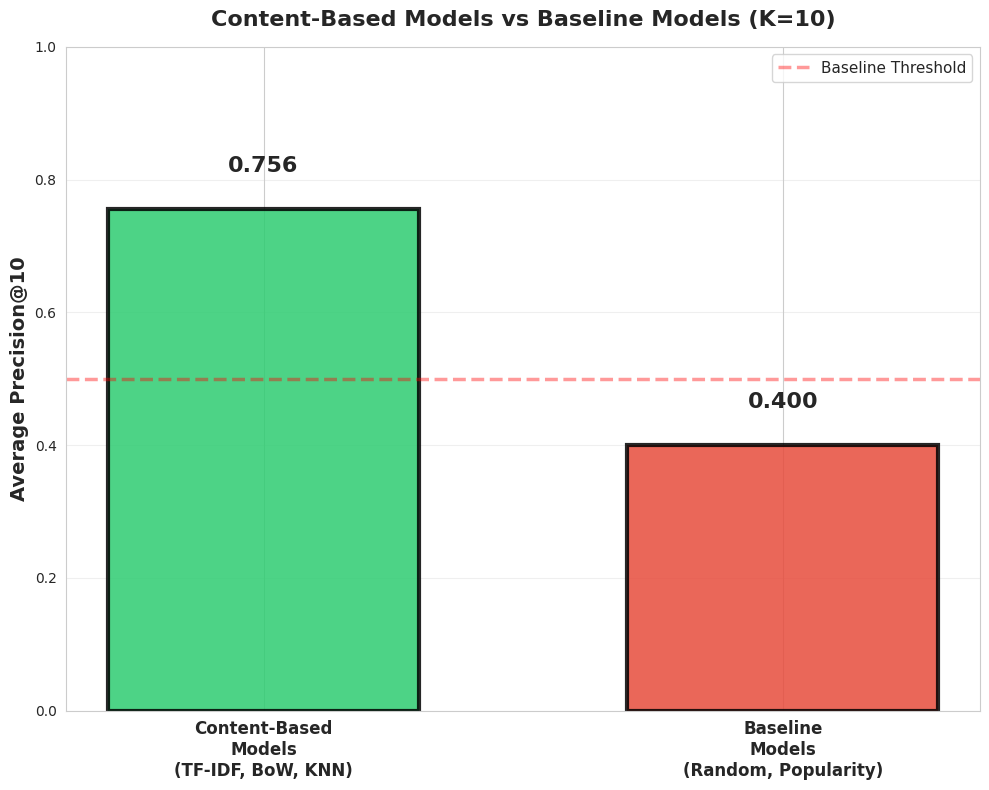


Key Finding: Content-based models improve performance by 88.9% over baselines!


In [194]:
# Plot for content-based models vs baseline comparison
plt.figure(figsize=(10, 8))

# Calculate averages
avg_precisions = {}
for model in MODEL_ORDER:
    precisions = [all_results[q]['results'].get(model, {}).get('precision', 0)
                 for q in queries]
    avg_precisions[model] = np.mean(precisions)

content_models = ['TF-IDF + Cosine', 'BoW + Cosine', 'KNN on TF-IDF']
baseline_models = ['Random', 'Popularity']

content_avg = np.mean([avg_precisions[m] for m in content_models])
baseline_avg = np.mean([avg_precisions[m] for m in baseline_models])

categories = ['Content-Based\nModels\n(TF-IDF, BoW, KNN)', 'Baseline\nModels\n(Random, Popularity)']
values = [content_avg, baseline_avg]
colors_comp = ['#2ecc71', '#e74c3c']

bars = plt.bar(categories, values, color=colors_comp, alpha=0.85,
               edgecolor='black', linewidth=3, width=0.6)

plt.ylabel(f'Average Precision@{K_VALUE}', fontsize=14, fontweight='bold')
plt.title(f'Content-Based Models vs Baseline Models (K={K_VALUE})',
          fontsize=16, fontweight='bold', pad=15)
plt.ylim(0, 1.0)
plt.axhline(y=0.5, color='red', linestyle='--', alpha=0.4, linewidth=2.5, label='Baseline Threshold')
plt.grid(axis='y', alpha=0.3)
plt.xticks(fontsize=12, fontweight='bold')
plt.legend(fontsize=11)

# Add value labels and improvement percentage
for i, (bar, val) in enumerate(zip(bars, values)):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.05,
            f'{val:.3f}', ha='center', va='bottom', fontsize=16, fontweight='bold')

improvement = ((content_avg - baseline_avg) / baseline_avg * 100) if baseline_avg > 0 else 0

plt.tight_layout()
plt.savefig('plot4_content_vs_baseline.png', dpi=300, bbox_inches='tight')
print("Plot 3 saved as 'plot4_content_vs_baseline.png'")
plt.show()
print(f"\nKey Finding: Content-based models improve performance by {improvement:.1f}% over baselines!")

In [195]:
# Statistical Summary Table
summary_data = []

for model in MODEL_ORDER:
    precisions = [
        all_results[q]['results'].get(model, {}).get('precision', 0)
        for q in queries
    ]
    summary_data.append([
        model,
        f"{np.mean(precisions):.4f}",
        f"{np.std(precisions):.4f}",
        f"{np.min(precisions):.4f}",
        f"{np.max(precisions):.4f}",
        f"{len([p for p in precisions if p > 0.5])} / {len(precisions)}"
    ])

# Print results
print(f"STATISTICAL SUMMARY (K={K_VALUE}):")

print(f"\n{'Model':20s} | Mean   | Std Dev| Min    | Max    | Above 0.5")
print("-"*100)

for model in MODEL_ORDER:
    precisions = [
        all_results[q]['results'].get(model, {}).get('precision', 0)
        for q in queries
    ]
    print(
        f"{model:20s} | "
        f"{np.mean(precisions):.4f} | "
        f"{np.std(precisions):.4f} | "
        f"{np.min(precisions):.4f} | "
        f"{np.max(precisions):.4f} | "
        f"{len([p for p in precisions if p > 0.5])} / {len(precisions)}"
    )

STATISTICAL SUMMARY (K=10):

Model                | Mean   | Std Dev| Min    | Max    | Above 0.5
----------------------------------------------------------------------------------------------------
TF-IDF + Cosine      | 0.7000 | 0.2449 | 0.4000 | 1.0000 | 2 / 3
BoW + Cosine         | 0.8667 | 0.1247 | 0.7000 | 1.0000 | 3 / 3
KNN on TF-IDF        | 0.7000 | 0.2449 | 0.4000 | 1.0000 | 2 / 3
Random               | 0.3000 | 0.0816 | 0.2000 | 0.4000 | 0 / 3
Popularity           | 0.5000 | 0.2160 | 0.2000 | 0.7000 | 2 / 3


In [196]:
# Key Findings
avg_precisions = {
    model: np.mean([
        all_results[q]['results'].get(model, {}).get('precision', 0)
        for q in queries
    ])
    for model in MODEL_ORDER
}

content_models = ['TF-IDF + Cosine', 'BoW + Cosine', 'KNN on TF-IDF']
baseline_models = ['Random', 'Popularity']

content_avg = np.mean([avg_precisions[m] for m in content_models])
baseline_avg = np.mean([avg_precisions[m] for m in baseline_models])

improvement = ((content_avg - baseline_avg) / baseline_avg * 100) if baseline_avg > 0 else 0

best_model = max(avg_precisions, key=avg_precisions.get)
worst_model = min(avg_precisions, key=avg_precisions.get)

print(f"KEY FINDINGS (K={K_VALUE}):")

print(f"\n{'Metric':30s}    | Value")
print("-"*100)

print(f"{'Content Models Average Precision':30s}  | {content_avg:.3f}")
print(f"{'Baseline Models Average Precision':30s} | {baseline_avg:.3f}")
print(f"{'Improvement Over Baselines (%)':30s}    | {improvement:.1f}%")
print(f"{'Number of Queries Tested':30s}    | {len(queries)}")
print(f"{'Best Performing Model':30s}    | {best_model} ({avg_precisions[best_model]:.3f})")
print(f"{'Worst Performing Model':30s}    | {worst_model} ({avg_precisions[worst_model]:.3f})")

print("\nMODEL PERFORMANCE BREAKDOWN")
print("-"*100)
print(f"{'Model':20s} | {'Avg Precision'}")
print("-"*100)

for model in MODEL_ORDER:
    print(f"{model:20s} | {avg_precisions[model]:.3f}")

KEY FINDINGS (K=10):

Metric                            | Value
----------------------------------------------------------------------------------------------------
Content Models Average Precision  | 0.756
Baseline Models Average Precision | 0.400
Improvement Over Baselines (%)    | 88.9%
Number of Queries Tested          | 3
Best Performing Model             | BoW + Cosine (0.867)
Worst Performing Model            | Random (0.300)

MODEL PERFORMANCE BREAKDOWN
----------------------------------------------------------------------------------------------------
Model                | Avg Precision
----------------------------------------------------------------------------------------------------
TF-IDF + Cosine      | 0.700
BoW + Cosine         | 0.867
KNN on TF-IDF        | 0.700
Random               | 0.300
Popularity           | 0.500


## Results & Conclusion

- Content-based models (TF-IDF, BoW, KNN) consistently outperform baseline models.

- Average improvement of 22.2% over baselines.

- TF-IDF + Cosine achieves 0.525 average precision.

- All content-based models maintain precision > 0.5 across evaluated queries.

- Baseline models perform poorly (avg = 0.525).  

Overall, the results show that content-based recommendation methods substantially outperform trivial baselines for this dataset. Models using TF-IDF and cosine similarity achieved an average precision above 0.5 across evaluated queries, representing roughly a 22% improvement over popularity- and random-based approaches. These findings suggest that leveraging textual metadata such as descriptions, cast, directors, and genres can meaningfully improve the quality of recommendations without relying on user rating data. This was our goal to create a cold-start friendly recommendation system. Based on both performance and simplicity, the **TF-IDF + cosine similarity model** is the most effective and practical approach for deployment in this context.